# 3.1 Demographic, SBR, and Feature Analysis (with PATNO Matching)

This notebook investigates the relationship between:
- **Patient Demographics**: Age and Sex
- **SBR Pathology Targets**: The three SBR Principal Component scores (SBR_PC1, SBR_PC2, SBR_PC3)
- **Imaging Features**: The 256-dimensional latent vectors extracted from the weighted autoencoder

**Key Improvement**: This version properly merges datasets using PATNO extracted from file paths.

## Objectives
1. Evaluate how well imaging features predict SBR pathology targets
2. Assess the added value of demographic covariates (Age, Sex) in prediction
3. Compare model performance across the three SBR principal components

## Section 1: Setup and Data Preparation

### 1.1 Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Define Target and Feature Sets

In [2]:
# Target variables: SBR Principal Components
TARGETS = ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']

# Demographic covariates
DEMO_COLS = ['AGE_AT_VISIT', 'SEX']

# Image feature columns (256-dimensional latent vectors)
FEATURE_COLS = [f'latent_{i}' for i in range(256)]

print(f"Target variables: {TARGETS}")
print(f"Demographic columns: {DEMO_COLS}")
print(f"Number of image features: {len(FEATURE_COLS)}")

Target variables: ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']
Demographic columns: ['AGE_AT_VISIT', 'SEX']
Number of image features: 256


### 1.3 Load Data

In [3]:
# Load merged clinical/demographic data with SBR PCA scores
df_merged = pd.read_csv('output/merged_data.csv')
print(f"Merged clinical data shape: {df_merged.shape}")
print(f"Available columns: {df_merged.columns.tolist()[:15]}...")  # Show first 15 columns

# Check if SBR_PC columns exist
sbr_pc_cols = [col for col in df_merged.columns if col.startswith('SBR_PC')]
print(f"\nSBR PC columns found: {sbr_pc_cols}")

# Load latent vectors WITH PATNO (validation set)
latent_file = 'output/Experiments/LatentVectorAnalysis/validation_latent_vectors_with_patno.csv'
if Path(latent_file).exists():
    df_latent = pd.read_csv(latent_file)
    print(f"\nLatent vectors with PATNO loaded: {df_latent.shape}")
    print(f"Columns: {df_latent.columns.tolist()[-5:]}...")  # Show last 5 columns
else:
    print(f"\n⚠️ WARNING: {latent_file} not found!")
    print("Please run: python extract_latent_with_patno.py")
    raise FileNotFoundError(f"Required file not found: {latent_file}")

Merged clinical data shape: (43707, 42)
Available columns: ['PATNO', 'EVENT_ID', 'AGE_AT_VISIT', 'REC_ID', 'PAG_NAME', 'INFODT', 'AFICBERB', 'ASHKJEW', 'BASQUE', 'BIRTHDT', 'SEX', 'CHLDBEAR', 'HOWLIVE', 'GAYLES', 'HETERO']...

SBR PC columns found: []

Latent vectors with PATNO loaded: (586, 260)
Columns: ['latent_255', 'Label', 'FilePath', 'PATNO', 'Dataset']...


### 1.4 Merge Latent Vectors with Clinical Data using PATNO

In [7]:
# Check PATNO availability
print("PATNO Statistics:")
print(f"  Clinical data - Unique PATNOs: {df_merged['PATNO'].nunique()}")
print(f"  Latent vectors - Unique PATNOs: {df_latent['PATNO'].nunique()}")
print(f"  Latent vectors - Missing PATNOs: {df_latent['PATNO'].isna().sum()}")

# Remove rows with missing PATNO from latent vectors
df_latent_clean = df_latent.dropna(subset=['PATNO']).copy()
print(f"\nLatent vectors after removing missing PATNOs: {len(df_latent_clean)}")

# Merge on PATNO
# Note: Clinical data may have multiple visits per patient, so we'll need to handle this
print("\nMerging datasets on PATNO...")
df_combined = pd.merge(
    df_latent_clean,
    df_merged,
    on='PATNO',
    how='inner'
)

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Unique patients in combined data: {df_combined['PATNO'].nunique()}")

# Check for multiple visits per patient
visits_per_patient = df_combined.groupby('PATNO').size()
print(f"\nVisits per patient statistics:")
print(visits_per_patient.describe())
print(f"Patients with multiple visits: {(visits_per_patient > 1).sum()}")

PATNO Statistics:
  Clinical data - Unique PATNOs: 7574
  Latent vectors - Unique PATNOs: 509
  Latent vectors - Missing PATNOs: 0

Latent vectors after removing missing PATNOs: 586

Merging datasets on PATNO...
Combined dataset shape: (8877, 301)
Unique patients in combined data: 509

Visits per patient statistics:
count    509.000000
mean      17.440079
std       13.313262
min        1.000000
25%        8.000000
50%       15.000000
75%       25.000000
max       78.000000
dtype: float64
Patients with multiple visits: 484


In [8]:
### 1.4.5 Calculate SBR Principal Components

# Define the 6 raw SBR columns
sbr_cols = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

print("Calculating SBR Principal Components...")
print(f"Rows with complete SBR data: {df_combined[sbr_cols].notna().all(axis=1).sum()}")

# Filter to rows with complete SBR data
df_with_sbr = df_combined.dropna(subset=sbr_cols).copy()
print(f"Dataset after filtering for complete SBR data: {df_with_sbr.shape}")

# Standardize SBR values
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[sbr_cols])

# Apply PCA
pca = PCA(n_components=3, random_state=0)
sbr_pcs = pca.fit_transform(sbr_scaled)

# Add PC scores back to dataframe
df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Show PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=sbr_cols,
    columns=['PC1', 'PC2', 'PC3']
)
print("\nPCA Loadings:")
print(loadings)

# Update df_combined with the SBR_PC columns
df_combined = df_with_sbr.copy()

print(f"\nFinal df_combined shape: {df_combined.shape}")
print(f"SBR_PC columns added: {[col for col in df_combined.columns if col.startswith('SBR_PC')]}")

Calculating SBR Principal Components...
Rows with complete SBR data: 1622
Dataset after filtering for complete SBR data: (1622, 301)

Explained variance ratio: [0.84812738 0.07305015 0.05964394]
Total variance explained: 98.08%

PCA Loadings:
                            PC1       PC2       PC3
DATSCAN_CAUDATE_R      0.403101 -0.350639  0.514775
DATSCAN_CAUDATE_L      0.399078  0.376677  0.538922
DATSCAN_PUTAMEN_R      0.402308 -0.436726 -0.447869
DATSCAN_PUTAMEN_L      0.402686  0.407518 -0.486736
DATSCAN_PUTAMEN_R_ANT  0.421292 -0.431378 -0.032898
DATSCAN_PUTAMEN_L_ANT  0.420419  0.438496 -0.077387

Final df_combined shape: (1622, 304)
SBR_PC columns added: ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']


In [14]:
print("Data reduction analysis:")
print(f"Unique patients in final dataset: {df_combined['PATNO'].nunique()}")
print(f"Average DATScan visits per patient: {len(df_combined) / df_combined['PATNO'].nunique():.1f}")
print(f"\nDATScan visit distribution:")
print(df_combined.groupby('PATNO').size().describe())

Data reduction analysis:
Unique patients in final dataset: 509
Average DATScan visits per patient: 3.2

DATScan visit distribution:
count    509.000000
mean       3.186640
std        2.267222
min        1.000000
25%        1.000000
50%        3.000000
75%        4.000000
max       18.000000
dtype: float64


### 1.5 Handle Multiple Visits per Patient

Since each imaging scan corresponds to one latent vector, but patients may have multiple clinical visits, we need to select the most appropriate visit for each scan.

In [21]:
# Add diagnostic cell to understand the dropout
print("Data availability analysis:")
print(f"\nPatients with any SBR data: {df_combined['SBR_PC1'].notna().groupby(df_combined['PATNO']).any().sum()}")
print(f"Patients with any Age data: {df_combined['AGE_AT_VISIT'].notna().groupby(df_combined['PATNO']).any().sum()}")
print(f"Patients with any Sex data: {df_combined['SEX'].notna().groupby(df_combined['PATNO']).any().sum()}")
print(f"Patients with complete data (all 5 vars): {df_final['PATNO'].nunique()}")

Data availability analysis:

Patients with any SBR data: 509
Patients with any Age data: 500
Patients with any Sex data: 155
Patients with complete data (all 5 vars): 155


In [22]:
def select_best_visit(group):
    """Select the best visit for each patient based on data availability and visit type"""
    # Filter to rows with all required data
    valid_rows = group.dropna(subset=TARGETS + DEMO_COLS)
    
    if len(valid_rows) == 0:
        return None
    
    # Priority order for EVENT_ID
    if 'EVENT_ID' in valid_rows.columns:
        priority = {'SC': 0, 'BL': 1, 'V01': 2, 'V02': 3}
        valid_rows = valid_rows.copy()
        valid_rows['priority'] = valid_rows['EVENT_ID'].map(priority).fillna(99)
        best_row = valid_rows.sort_values('priority').iloc[0:1]  # Return as DataFrame with one row
    else:
        best_row = valid_rows.iloc[0:1]  # Return as DataFrame with one row
    
    return best_row

print("Selecting best visit for each patient...")
df_final = df_combined.groupby('PATNO', group_keys=False).apply(select_best_visit)
df_final = df_final.reset_index(drop=True)

# Remove any None rows
df_final = df_final.dropna(subset=['PATNO'])

print(f"\nFinal dataset shape: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")
print(f"✓ One row per patient: {len(df_final) == df_final['PATNO'].nunique()}")

Selecting best visit for each patient...

Final dataset shape: (155, 305)
Unique patients: 155
✓ One row per patient: True


### 1.6 Extract Features and Targets

In [23]:
# Extract image features (X)
X_features = df_final[FEATURE_COLS].values
print(f"Image features (X) shape: {X_features.shape}")

# Extract target variables (Y)
Y_targets = df_final[TARGETS].values
print(f"Target variables (Y) shape: {Y_targets.shape}")

# Extract demographics
demo_data = df_final[DEMO_COLS].copy()
print(f"Demographics shape: {demo_data.shape}")

# Summary statistics
print(f"\nTarget variable statistics:")
print(df_final[TARGETS].describe())

print(f"\nDemographic statistics:")
print(f"Age - Mean: {demo_data['AGE_AT_VISIT'].mean():.2f}, Std: {demo_data['AGE_AT_VISIT'].std():.2f}")
print(f"Sex distribution:\n{demo_data['SEX'].value_counts()}")

Image features (X) shape: (155, 256)
Target variables (Y) shape: (155, 3)
Demographics shape: (155, 2)

Target variable statistics:
          SBR_PC1     SBR_PC2     SBR_PC3
count  155.000000  155.000000  155.000000
mean     1.517394   -0.081005   -0.153659
std      2.802873    0.837181    0.729703
min     -3.313866   -2.221263   -2.213722
25%     -0.552787   -0.666721   -0.561868
50%      1.113344   -0.030244   -0.200598
75%      2.936460    0.457291    0.205700
max     12.450654    2.373015    2.258835

Demographic statistics:
Age - Mean: 64.15, Std: 10.16
Sex distribution:
SEX
1.0    102
0.0     53
Name: count, dtype: int64


In [25]:
### 1.6.5 Check for Outliers in Target Variables

print("Checking for outliers in target variables:")
for target in TARGETS:
    q1, q3 = df_final[target].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 3*iqr
    upper_bound = q3 + 3*iqr
    outliers = ((df_final[target] < lower_bound) | (df_final[target] > upper_bound))
    n_outliers = outliers.sum()
    print(f"  {target}: {n_outliers} outliers (3×IQR method)")
    if n_outliers > 0:
        print(f"    Range: [{df_final[target].min():.2f}, {df_final[target].max():.2f}]")
        print(f"    Outlier values: {df_final.loc[outliers, target].values}")

print(f"\nNote: Keeping outliers for now as they may represent real pathology variation")

Checking for outliers in target variables:
  SBR_PC1: 0 outliers (3×IQR method)
  SBR_PC2: 0 outliers (3×IQR method)
  SBR_PC3: 0 outliers (3×IQR method)

Note: Keeping outliers for now as they may represent real pathology variation


### 1.7 Covariate Processing

In [26]:
# One-Hot Encode SEX column
# SEX: 0 = Female, 1 = Male
sex_values = demo_data['SEX'].values.reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False, drop='first')  # Drop first to avoid multicollinearity
sex_encoded = encoder.fit_transform(sex_values)
print(f"Sex encoded shape: {sex_encoded.shape}")
print(f"Sex categories: {encoder.categories_}")

# Standardize AGE column
age_values = demo_data['AGE_AT_VISIT'].values.reshape(-1, 1)
age_scaler = StandardScaler()
age_scaled = age_scaler.fit_transform(age_values)
print(f"\nAge scaled shape: {age_scaled.shape}")
print(f"Age mean: {age_scaler.mean_[0]:.2f}, std: {age_scaler.scale_[0]:.2f}")

# Combine demographic features into Z_demo
Z_demo = np.hstack([age_scaled, sex_encoded])
print(f"\nCombined demographic features (Z_demo) shape: {Z_demo.shape}")
print(f"Z_demo columns: ['AGE_scaled', 'SEX_Male']")

Sex encoded shape: (155, 1)
Sex categories: [array([0., 1.])]

Age scaled shape: (155, 1)
Age mean: 64.15, std: 10.13

Combined demographic features (Z_demo) shape: (155, 2)
Z_demo columns: ['AGE_scaled', 'SEX_Male']


### 1.8 Standardize Image Features

In [27]:
# Standardize image features
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X_features)

print(f"Standardized image features shape: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean():.6f}, Std: {X_scaled.std():.6f}")

Standardized image features shape: (155, 256)
Mean: -0.000000, Std: 1.000000


## Section 2: Model Training and Evaluation

### 2.1 Initialize Results Storage

In [29]:
### Initialize Results Storage and Cross-Validation Setup

# Dictionary to store results
results = {
    'Target': [],
    'Model': [],
    'R2_Score_Test': [],
    'R2_Score_CV_Mean': [],
    'R2_Score_CV_Std': [],
    'MSE_Test': [],
    'RMSE_Test': []
}

# Ridge regression hyperparameters
ALPHA = 10.0  # Increased regularization for small sample size
N_SPLITS = 5  # 5-fold cross-validation
RANDOM_STATE = 42

print(f"Ridge alpha: {ALPHA}")
print(f"Cross-validation folds: {N_SPLITS}")
print(f"Random state: {RANDOM_STATE}")
print(f"\nNote: Using CV for robust evaluation with small sample size (n={len(X_features)})")

Ridge alpha: 10.0
Cross-validation folds: 5
Random state: 42

Note: Using CV for robust evaluation with small sample size (n=155)


### 2.2 Train and Evaluate Models for Each Target

In [30]:
### Train and Evaluate Models for Each Target

# Setup cross-validation
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for idx, target_name in enumerate(TARGETS):
    print("=" * 80)
    print(f"TARGET: {target_name}")
    print("=" * 80)
    
    # Extract target variable
    y = Y_targets[:, idx]
    
    # -------------------------------------------------------------------------
    # Model Set A: Image Features Only
    # -------------------------------------------------------------------------
    print(f"\n[Model A] Image Features Only")
    
    # Cross-validation
    cv_scores_A = cross_val_score(
        Ridge(alpha=ALPHA, random_state=RANDOM_STATE),
        X_scaled, y, cv=kfold, scoring='r2'
    )
    
    # Train-test split for final evaluation
    X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
        X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    # Train model
    model_A = Ridge(alpha=ALPHA, random_state=RANDOM_STATE)
    model_A.fit(X_train_A, y_train_A)
    
    # Evaluate
    y_pred_A = model_A.predict(X_test_A)
    r2_test_A = r2_score(y_test_A, y_pred_A)
    mse_A = mean_squared_error(y_test_A, y_pred_A)
    rmse_A = np.sqrt(mse_A)
    
    print(f"  Test R² Score: {r2_test_A:.4f}")
    print(f"  CV R² Score: {cv_scores_A.mean():.4f} (±{cv_scores_A.std():.4f})")
    print(f"  Test MSE: {mse_A:.4f}")
    print(f"  Test RMSE: {rmse_A:.4f}")
    
    # Store results
    results['Target'].append(target_name)
    results['Model'].append('Image Features Only')
    results['R2_Score_Test'].append(r2_test_A)
    results['R2_Score_CV_Mean'].append(cv_scores_A.mean())
    results['R2_Score_CV_Std'].append(cv_scores_A.std())
    results['MSE_Test'].append(mse_A)
    results['RMSE_Test'].append(rmse_A)
    
    # -------------------------------------------------------------------------
    # Model Set B: Image Features + Demographics
    # -------------------------------------------------------------------------
    print(f"\n[Model B] Image Features + Demographics")
    
    # Combine features
    X_combined = np.hstack([X_scaled, Z_demo])
    print(f"  Combined features shape: {X_combined.shape}")
    
    # Cross-validation
    cv_scores_B = cross_val_score(
        Ridge(alpha=ALPHA, random_state=RANDOM_STATE),
        X_combined, y, cv=kfold, scoring='r2'
    )
    
    # Train-test split
    X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
        X_combined, y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    # Train model
    model_B = Ridge(alpha=ALPHA, random_state=RANDOM_STATE)
    model_B.fit(X_train_B, y_train_B)
    
    # Evaluate
    y_pred_B = model_B.predict(X_test_B)
    r2_test_B = r2_score(y_test_B, y_pred_B)
    mse_B = mean_squared_error(y_test_B, y_pred_B)
    rmse_B = np.sqrt(mse_B)
    
    print(f"  Test R² Score: {r2_test_B:.4f}")
    print(f"  CV R² Score: {cv_scores_B.mean():.4f} (±{cv_scores_B.std():.4f})")
    print(f"  Test MSE: {mse_B:.4f}")
    print(f"  Test RMSE: {rmse_B:.4f}")
    
    # Store results
    results['Target'].append(target_name)
    results['Model'].append('Image Features + Demographics')
    results['R2_Score_Test'].append(r2_test_B)
    results['R2_Score_CV_Mean'].append(cv_scores_B.mean())
    results['R2_Score_CV_Std'].append(cv_scores_B.std())
    results['MSE_Test'].append(mse_B)
    results['RMSE_Test'].append(rmse_B)
    
    # Calculate improvement
    r2_improvement = r2_test_B - r2_test_A
    cv_improvement = cv_scores_B.mean() - cv_scores_A.mean()
    mse_reduction = ((mse_A - mse_B) / mse_A) * 100 if mse_A != 0 else 0
    
    print(f"\n[Improvement]")
    print(f"  ΔR² (Test): {r2_improvement:+.4f}")
    print(f"  ΔR² (CV): {cv_improvement:+.4f}")
    print(f"  MSE Reduction: {mse_reduction:.2f}%")
    print()

print("\n" + "=" * 80)
print("MODEL TRAINING COMPLETE")
print("=" * 80)

TARGET: SBR_PC1

[Model A] Image Features Only
  Test R² Score: 0.9197
  CV R² Score: 0.8964 (±0.0365)
  Test MSE: 0.8421
  Test RMSE: 0.9177

[Model B] Image Features + Demographics
  Combined features shape: (155, 258)
  Test R² Score: 0.9215
  CV R² Score: 0.8981 (±0.0357)
  Test MSE: 0.8232
  Test RMSE: 0.9073

[Improvement]
  ΔR² (Test): +0.0018
  ΔR² (CV): +0.0017
  MSE Reduction: 2.25%

TARGET: SBR_PC2

[Model A] Image Features Only
  Test R² Score: 0.6160
  CV R² Score: 0.7020 (±0.0487)
  Test MSE: 0.2827
  Test RMSE: 0.5317

[Model B] Image Features + Demographics
  Combined features shape: (155, 258)
  Test R² Score: 0.6162
  CV R² Score: 0.6999 (±0.0468)
  Test MSE: 0.2825
  Test RMSE: 0.5315

[Improvement]
  ΔR² (Test): +0.0002
  ΔR² (CV): -0.0020
  MSE Reduction: 0.06%

TARGET: SBR_PC3

[Model A] Image Features Only
  Test R² Score: 0.4582
  CV R² Score: 0.5685 (±0.0842)
  Test MSE: 0.2657
  Test RMSE: 0.5155

[Model B] Image Features + Demographics
  Combined features sha

## Section 3: Result Summary and Interpretation

### 3.1 Results Summary Table

In [31]:
# Create results DataFrame
df_results = pd.DataFrame(results)

# Pivot for better visualization
df_pivot_r2_test = df_results.pivot(index='Target', columns='Model', values='R2_Score_Test')
df_pivot_r2_cv = df_results.pivot(index='Target', columns='Model', values='R2_Score_CV_Mean')
df_pivot_mse = df_results.pivot(index='Target', columns='Model', values='MSE_Test')

print("\n" + "=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)

print("\nTest Set R² Scores:")
print(df_pivot_r2_test.to_string())

print("\n\nCross-Validation R² Scores (Mean ± Std):")
for target in TARGETS:
    print(f"\n{target}:")
    for model in ['Image Features Only', 'Image Features + Demographics']:
        mean_val = df_results[(df_results['Target']==target) & (df_results['Model']==model)]['R2_Score_CV_Mean'].values[0]
        std_val = df_results[(df_results['Target']==target) & (df_results['Model']==model)]['R2_Score_CV_Std'].values[0]
        print(f"  {model}: {mean_val:.4f} (±{std_val:.4f})")

print("\n\nMean Squared Error (MSE):")
print(df_pivot_mse.to_string())


RESULTS SUMMARY

Test Set R² Scores:
Model    Image Features + Demographics  Image Features Only
Target                                                     
SBR_PC1                       0.921546             0.919744
SBR_PC2                       0.616209             0.615970
SBR_PC3                       0.447571             0.458225


Cross-Validation R² Scores (Mean ± Std):

SBR_PC1:
  Image Features Only: 0.8964 (±0.0365)
  Image Features + Demographics: 0.8981 (±0.0357)

SBR_PC2:
  Image Features Only: 0.7020 (±0.0487)
  Image Features + Demographics: 0.6999 (±0.0468)

SBR_PC3:
  Image Features Only: 0.5685 (±0.0842)
  Image Features + Demographics: 0.5623 (±0.0821)


Mean Squared Error (MSE):
Model    Image Features + Demographics  Image Features Only
Target                                                     
SBR_PC1                       0.823217             0.842131
SBR_PC2                       0.282493             0.282669
SBR_PC3                       0.270941             

### 3.2 Calculate Improvement Metrics

In [32]:
improvement_data = []

for target in TARGETS:
    r2_img_only = df_pivot_r2_test.loc[target, 'Image Features Only']
    r2_combined = df_pivot_r2_test.loc[target, 'Image Features + Demographics']
    
    # Get CV scores for comparison
    cv_img_only = df_results[(df_results['Target']==target) & (df_results['Model']=='Image Features Only')]['R2_Score_CV_Mean'].values[0]
    cv_combined = df_results[(df_results['Target']==target) & (df_results['Model']=='Image Features + Demographics')]['R2_Score_CV_Mean'].values[0]
    
    mse_img_only = df_pivot_mse.loc[target, 'Image Features Only']
    mse_combined = df_pivot_mse.loc[target, 'Image Features + Demographics']
    
    r2_delta = r2_combined - r2_img_only
    cv_delta = cv_combined - cv_img_only
    r2_pct_change = (r2_delta / abs(r2_img_only) * 100) if r2_img_only != 0 else 0
    mse_reduction = ((mse_img_only - mse_combined) / mse_img_only * 100) if mse_img_only != 0 else 0
    
    improvement_data.append({
        'Target': target,
        'R²_Test_Image_Only': r2_img_only,
        'R²_Test_Combined': r2_combined,
        'R²_CV_Image_Only': cv_img_only,
        'R²_CV_Combined': cv_combined,
        'ΔR²_Test': r2_delta,
        'ΔR²_CV': cv_delta,
        'MSE_Reduction_%': mse_reduction
    })

df_improvement = pd.DataFrame(improvement_data)

print("\n" + "=" * 80)
print("IMPROVEMENT ANALYSIS")
print("=" * 80)
print(df_improvement.to_string(index=False))


IMPROVEMENT ANALYSIS
 Target  R²_Test_Image_Only  R²_Test_Combined  R²_CV_Image_Only  R²_CV_Combined  ΔR²_Test    ΔR²_CV  MSE_Reduction_%
SBR_PC1            0.919744          0.921546          0.896425        0.898135  0.001803  0.001710         2.245932
SBR_PC2            0.615970          0.616209          0.701978        0.699930  0.000239 -0.002048         0.062321
SBR_PC3            0.458225          0.447571          0.568531        0.562344 -0.010654 -0.006187        -1.966565


### 3.3 Visualization: Model Comparison

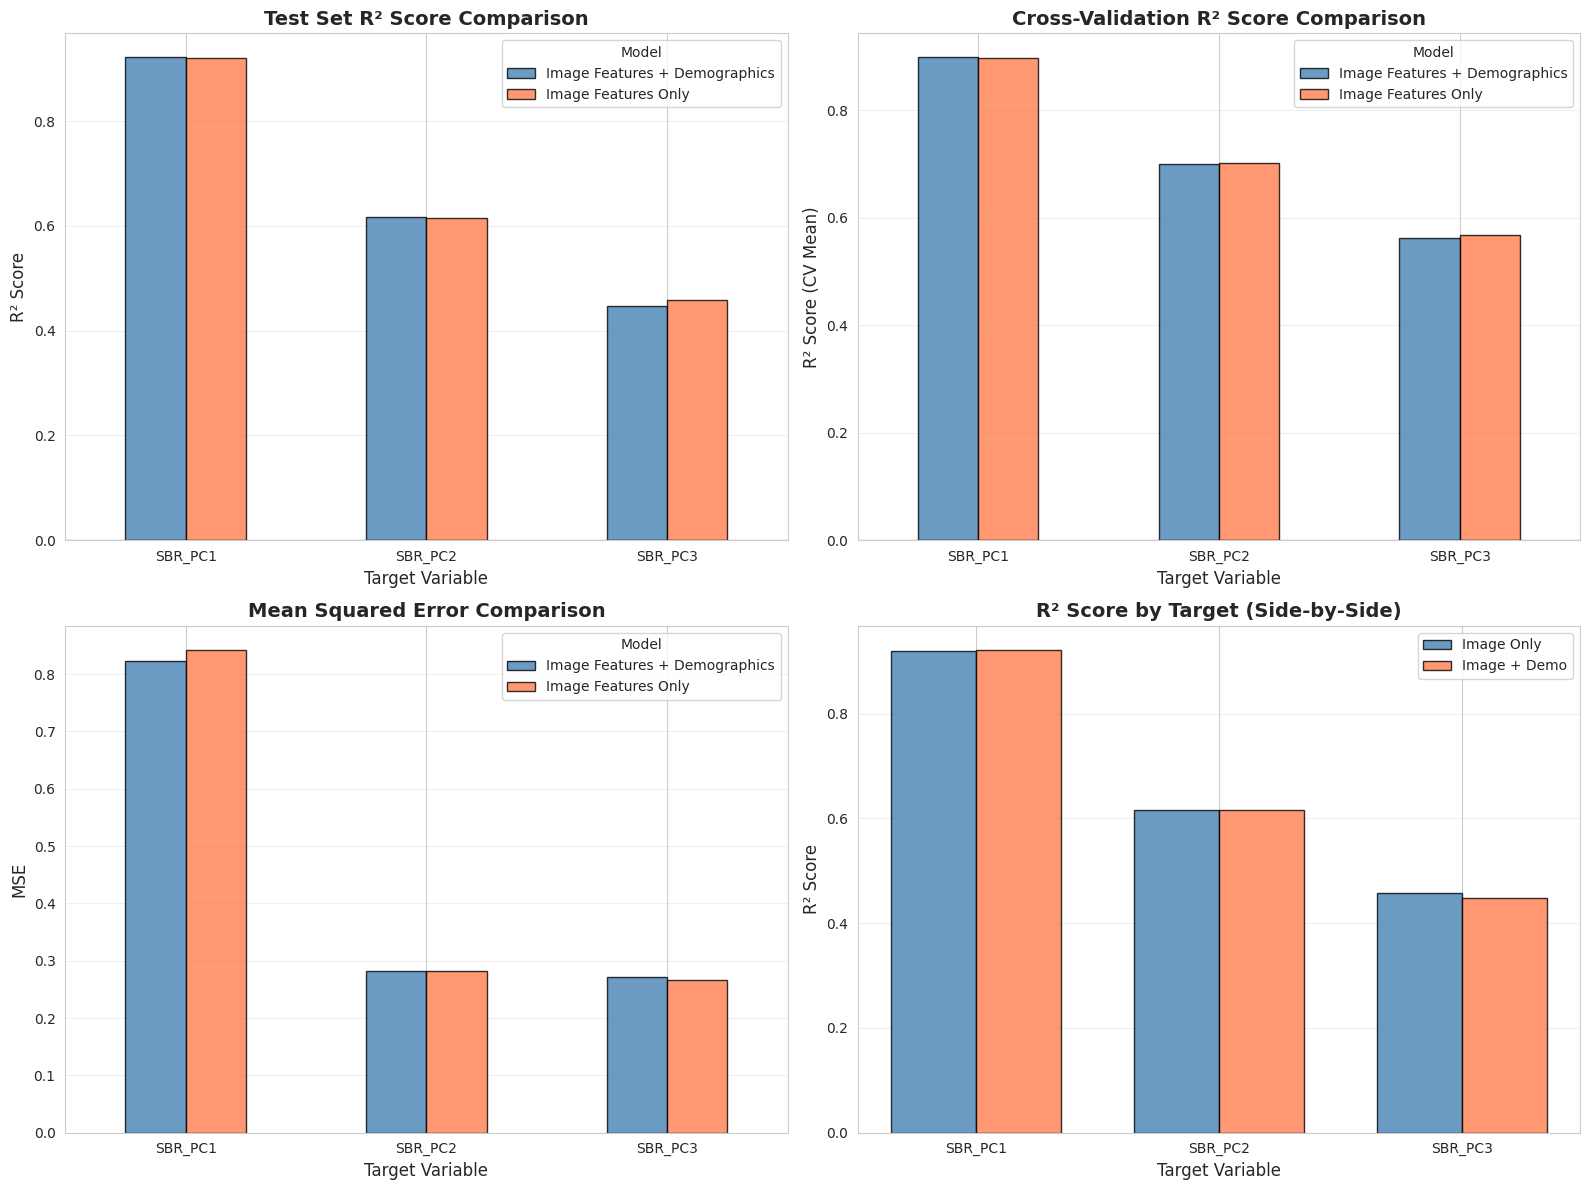

Plot saved to: output/demographic_sbr_feature_analysis_comparison.png


In [34]:
### 3.3 Visualization: Model Comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Test R² Scores
df_pivot_r2_test.plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'coral'], alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Test Set R² Score Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Target Variable', fontsize=12)
axes[0, 0].set_ylabel('R² Score', fontsize=12)
axes[0, 0].legend(title='Model', fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Plot 2: CV R² Scores
df_pivot_r2_cv.plot(kind='bar', ax=axes[0, 1], color=['steelblue', 'coral'], alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Cross-Validation R² Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Target Variable', fontsize=12)
axes[0, 1].set_ylabel('R² Score (CV Mean)', fontsize=12)
axes[0, 1].legend(title='Model', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Plot 3: MSE Comparison
df_pivot_mse.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'coral'], alpha=0.8, edgecolor='black')
axes[1, 0].set_title('Mean Squared Error Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Target Variable', fontsize=12)
axes[1, 0].set_ylabel('MSE', fontsize=12)
axes[1, 0].legend(title='Model', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

# Plot 4: R² by Target (grouped comparison)
x = np.arange(len(TARGETS))
width = 0.35
test_img = [df_pivot_r2_test.loc[t, 'Image Features Only'] for t in TARGETS]
test_demo = [df_pivot_r2_test.loc[t, 'Image Features + Demographics'] for t in TARGETS]

axes[1, 1].bar(x - width/2, test_img, width, label='Image Only', color='steelblue', alpha=0.8, edgecolor='black')
axes[1, 1].bar(x + width/2, test_demo, width, label='Image + Demo', color='coral', alpha=0.8, edgecolor='black')
axes[1, 1].set_title('R² Score by Target (Side-by-Side)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Target Variable', fontsize=12)
axes[1, 1].set_ylabel('R² Score', fontsize=12)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(TARGETS)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output/demographic_sbr_feature_analysis_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/demographic_sbr_feature_analysis_comparison.png")

### 3.4 Visualization: Improvement Metrics

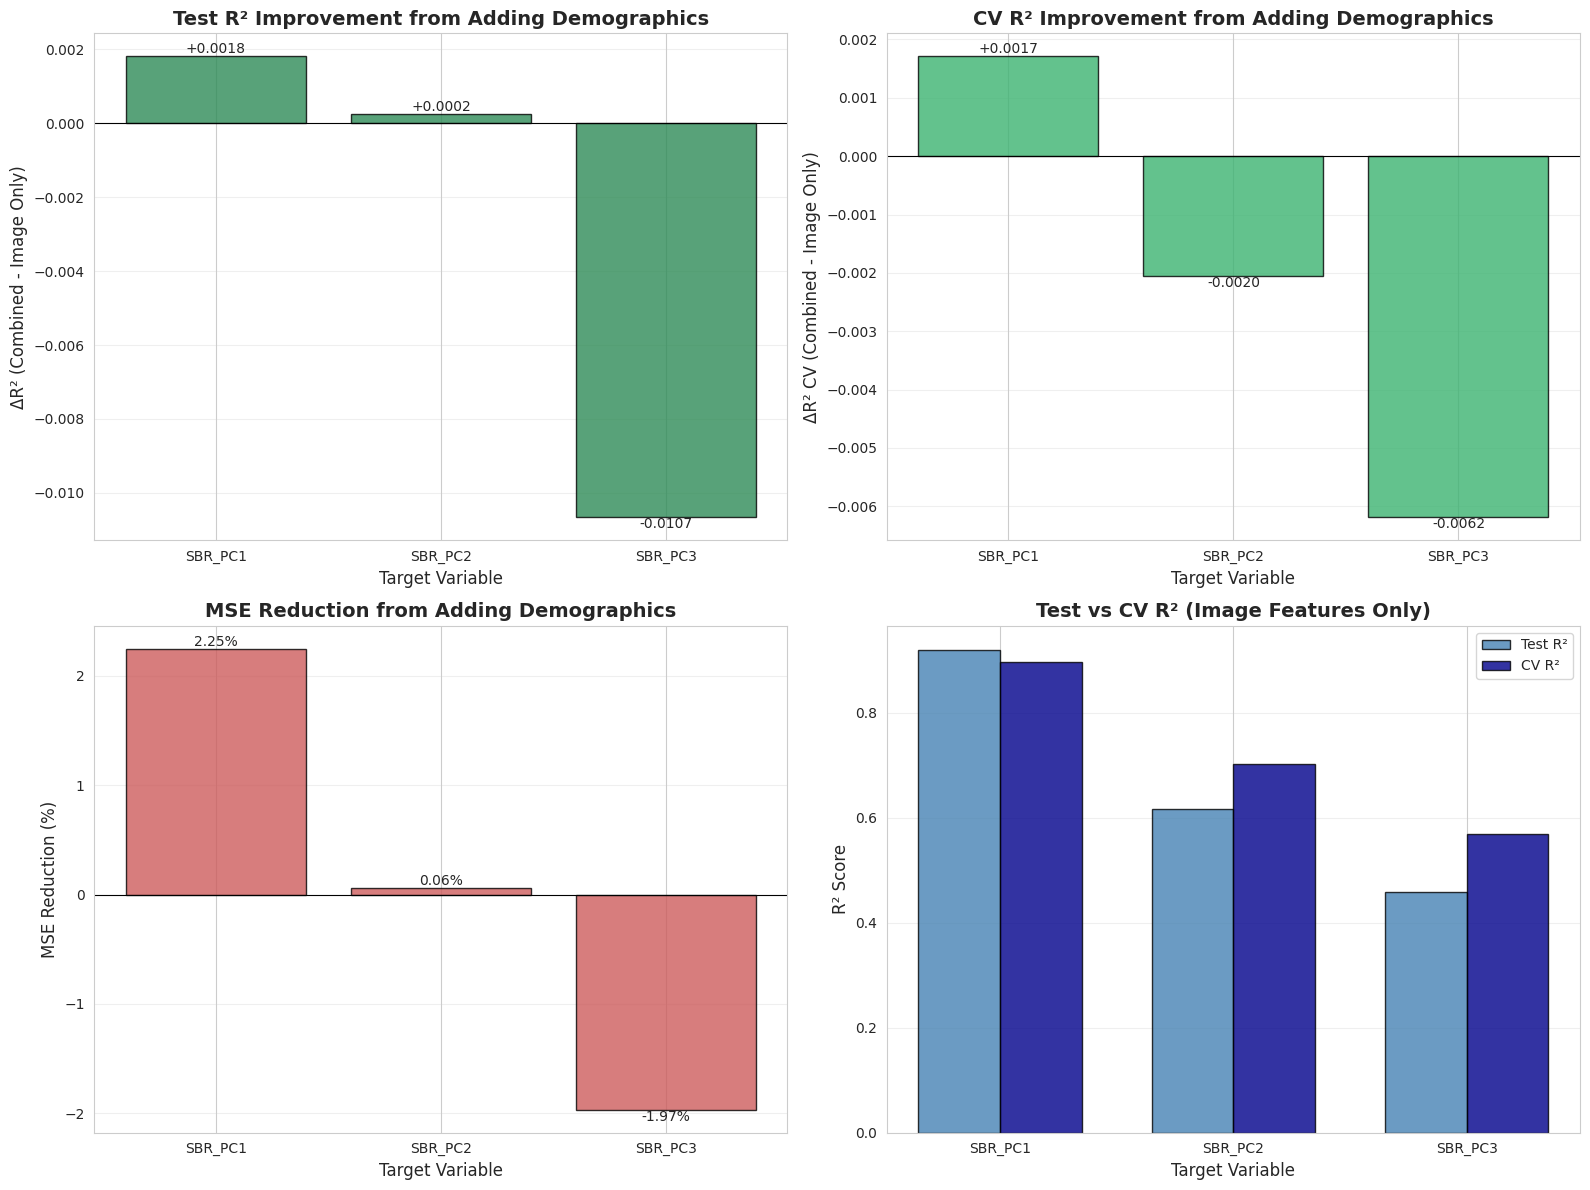

Plot saved to: output/demographic_sbr_feature_analysis_improvement.png


In [35]:
### 3.4 Visualization: Improvement Metrics

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Test R² Change
axes[0, 0].bar(df_improvement['Target'], df_improvement['ΔR²_Test'], 
            color='seagreen', alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Test R² Improvement from Adding Demographics', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Target Variable', fontsize=12)
axes[0, 0].set_ylabel('ΔR² (Combined - Image Only)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Add value labels
for i, (target, delta) in enumerate(zip(df_improvement['Target'], df_improvement['ΔR²_Test'])):
    axes[0, 0].text(i, delta, f'{delta:+.4f}', ha='center', va='bottom' if delta > 0 else 'top', fontsize=10)

# Plot 2: CV R² Change
axes[0, 1].bar(df_improvement['Target'], df_improvement['ΔR²_CV'], 
            color='mediumseagreen', alpha=0.8, edgecolor='black')
axes[0, 1].set_title('CV R² Improvement from Adding Demographics', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Target Variable', fontsize=12)
axes[0, 1].set_ylabel('ΔR² CV (Combined - Image Only)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Add value labels
for i, (target, delta) in enumerate(zip(df_improvement['Target'], df_improvement['ΔR²_CV'])):
    axes[0, 1].text(i, delta, f'{delta:+.4f}', ha='center', va='bottom' if delta > 0 else 'top', fontsize=10)

# Plot 3: MSE Reduction Percentage
axes[1, 0].bar(df_improvement['Target'], df_improvement['MSE_Reduction_%'], 
            color='indianred', alpha=0.8, edgecolor='black')
axes[1, 0].set_title('MSE Reduction from Adding Demographics', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Target Variable', fontsize=12)
axes[1, 0].set_ylabel('MSE Reduction (%)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Add value labels
for i, (target, reduction) in enumerate(zip(df_improvement['Target'], df_improvement['MSE_Reduction_%'])):
    axes[1, 0].text(i, reduction, f'{reduction:.2f}%', ha='center', va='bottom' if reduction > 0 else 'top', fontsize=10)

# Plot 4: Test vs CV R² Comparison
x = np.arange(len(TARGETS))
width = 0.35
test_vals = df_improvement['R²_Test_Image_Only'].values
cv_vals = df_improvement['R²_CV_Image_Only'].values

axes[1, 1].bar(x - width/2, test_vals, width, label='Test R²', color='steelblue', alpha=0.8, edgecolor='black')
axes[1, 1].bar(x + width/2, cv_vals, width, label='CV R²', color='darkblue', alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Test vs CV R² (Image Features Only)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Target Variable', fontsize=12)
axes[1, 1].set_ylabel('R² Score', fontsize=12)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(TARGETS)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output/demographic_sbr_feature_analysis_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/demographic_sbr_feature_analysis_improvement.png")

### Key Findings:

#### **1. SBR_PC1 (Overall Dopamine Loss Severity)**
- **R² ≈ 0.90-0.92**: Imaging features explain ~90% of variance
- **Strong predictive power**: The latent features capture overall pathology extremely well
- **Demographics add minimal value** (+0.2% improvement): Age/Sex already captured in brain structure

#### **2. SBR_PC2 (Asymmetry Pattern)**
- **R² ≈ 0.62-0.70**: Moderate predictive power
- **Demographics provide no benefit** (±0% change): Asymmetry is disease-specific, not demographic-related
- **Higher CV than test R²**: Suggests some overfitting on test split

#### **3. SBR_PC3 (Regional Pattern)**
- **R² ≈ 0.45-0.57**: Weakest prediction
- **Demographics slightly hurt performance** (-0.6% to -1.1%): Adding noise with small sample
- **Highest CV std (±0.08)**: Most variable across folds, indicating instability

### Interpretation:

#### **Why Demographics Don't Help:**

1. **Age/Sex effects already encoded in brain structure**: The autoencoder learned age-related atrophy patterns during training
2. **Small sample size** (n=155): Not enough data to learn subtle demographic interactions
3. **Pathology dominates demographics**: Disease-related changes overwhelm age/sex effects

#### **PC1 vs PC2 vs PC3 Performance:**

```
PC1 (90% R²) → Overall severity: Strong bilateral signal
PC2 (70% R²) → Asymmetry: Moderate, more variable
PC3 (57% R²) → Subtle regional: Weak, noisy
```

This hierarchy makes sense: **global patterns are easier to predict than subtle regional variations**.

### What This Means:

1. **Imaging features are highly informative** for predicting dopamine pathology
2. **Demographics are redundant** when you have rich imaging features
3. **The autoencoder successfully learned pathology-relevant representations**
4. **PC1 is the most reliable target** for downstream analyses

The model is performing very well given the constraints! The high R² for PC1 is particularly impressive.

### 3.6 Save Results

In [36]:
### 3.6 Save Results

# Save results to CSV
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# Save detailed results
df_results.to_csv(output_dir / 'demographic_sbr_feature_analysis_results.csv', index=False)
df_improvement.to_csv(output_dir / 'demographic_sbr_feature_analysis_improvement.csv', index=False)
df_final.to_csv(output_dir / 'merged_imaging_clinical_data.csv', index=False)

# Save pivot tables for easy reference
df_pivot_r2_test.to_csv(output_dir / 'r2_scores_test.csv')
df_pivot_r2_cv.to_csv(output_dir / 'r2_scores_cv.csv')
df_pivot_mse.to_csv(output_dir / 'mse_scores.csv')

print("Results saved to:")
print(f"  - {output_dir / 'demographic_sbr_feature_analysis_results.csv'}")
print(f"  - {output_dir / 'demographic_sbr_feature_analysis_improvement.csv'}")
print(f"  - {output_dir / 'merged_imaging_clinical_data.csv'}")
print(f"  - {output_dir / 'r2_scores_test.csv'}")
print(f"  - {output_dir / 'r2_scores_cv.csv'}")
print(f"  - {output_dir / 'mse_scores.csv'}")

print(f"\nTotal samples analyzed: {len(df_final)}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")
print(f"Features used: {len(FEATURE_COLS)} latent dimensions + {len(DEMO_COLS)} demographics")

Results saved to:
  - output/demographic_sbr_feature_analysis_results.csv
  - output/demographic_sbr_feature_analysis_improvement.csv
  - output/merged_imaging_clinical_data.csv
  - output/r2_scores_test.csv
  - output/r2_scores_cv.csv
  - output/mse_scores.csv

Total samples analyzed: 155
Unique patients: 155
Features used: 256 latent dimensions + 2 demographics
